# Modeling — Shakespeare Authorship Verification

Loads `features.pkl` from `02_feature_engineering` notebook and:
1. Visualizes the feature space with PCA (diagnostic only, not used for training)
2. Trains and cross-validates multiple classifiers (logistic regression, SVM, random forest, gradient boosting)
3. Evaluates all models on the held-out test set
4. Picks the best model and runs it on the disputed texts to produce authorship probability scores


## Load features

In [ ]:
import pickle
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
BASE_PATH = "/content/drive/MyDrive/shakespeare_project/"

with open(BASE_PATH + "features.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]
X_disputed = data["X_disputed"]
train_df = data["train_df"]
test_df = data["test_df"]
disputed_df = data["disputed_df"]
print("X_train:", X_train.shape, " X_test:", X_test.shape, " X_disputed:", X_disputed.shape)

X_train: (907, 2182)  X_test: (264, 2182)  X_disputed: (106, 2182)


In [ ]:
print("Jonson play(s) in test set:", test_df[test_df["author"] == "jonson"]["play"].unique())
print("Marlowe play(s) in test set:", test_df[test_df["author"] == "marlowe"]["play"].unique())

for author in test_df["author"].unique():
    print(f"{author}: {test_df[test_df['author'] == author]['play'].unique()}")

Jonson play(s) in test set: ['jonson_bartholomew_fair.txt']
Marlowe play(s) in test set: ['marlowe_edward_the_second.txt']
shakespeare: ['much_ado_about_nothing.txt' 'pericles_prince_of_tyre.txt'
 'the_life_of_timon_of_athens.txt' 'the_merry_wives_of_windsor.txt'
 'the_taming_of_the_shrew.txt' 'the_tragedy_of_macbeth.txt'
 'troilus_and_cressida.txt']
fletcher: ['fletcher_the_chances.txt']
greene: ['greene_friar_bacon_and_friar_bungay.txt']
jonson: ['jonson_bartholomew_fair.txt']
kyd: ['kyd_the_tragedy_of_soliman_and_perseda.txt']
marlowe: ['marlowe_edward_the_second.txt']
massinger: ['massinger_the_bondman.txt']


## PCA visualization (diagnostic only)

Explained variance (PC1, PC2): [0.22942521 0.08422572]
Total variance captured in 2D: 31.4%


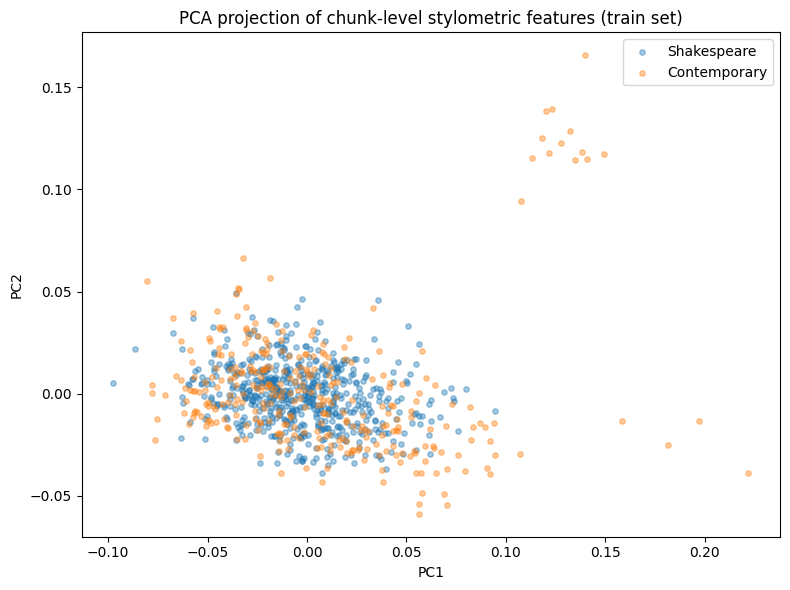

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

print(f"Explained variance (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total variance captured in 2D: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1],
            alpha=0.4, label="Shakespeare", s=15)
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1],
            alpha=0.4, label="Contemporary", s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of chunk-level stylometric features (train set)")
plt.legend()
plt.tight_layout()
plt.show()

## Train classifiers

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
models = {
    "Logistic Regression": (LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42), True),
    "SVM (linear)": (SVC(kernel="linear", class_weight="balanced", probability=True, random_state=42), True),
    "Random Forest": (RandomForestClassifier(class_weight="balanced", n_estimators=200, n_jobs=-1, random_state=42), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), False),
}

def manual_cv_f1(model, X, y, groups, needs_scaling=False, needs_sample_weight=False, n_splits=5, seed=42):
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []

    for train_idx, val_idx in skf.split(X, y, groups=groups):
        m = clone(model)
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        if needs_scaling:
            fold_scaler = StandardScaler()
            X_tr = fold_scaler.fit_transform(X_tr)
            X_val = fold_scaler.transform(X_val)

        if needs_sample_weight:
            sw = compute_sample_weight("balanced", y_tr)
            m.fit(X_tr, y_tr, sample_weight=sw)
        else:
            m.fit(X_tr, y_tr)

        y_pred = m.predict(X_val)
        scores.append(f1_score(y_val, y_pred, average="macro"))
    return np.array(scores)

groups_train = train_df["play"].values

cv_results = {}
for name, (model, needs_scaling) in models.items():
    needs_sw = (name == "Gradient Boosting")
    scores = manual_cv_f1(model, X_train, y_train, groups_train, needs_scaling=needs_scaling, needs_sample_weight=needs_sw)
    cv_results[name] = scores
    print(f"{name:<22} Macro F1 (5-fold CV): {scores.mean():.3f} +/- {scores.std():.3f}")

Logistic Regression    Macro F1 (5-fold CV): 0.906 +/- 0.032
SVM (linear)           Macro F1 (5-fold CV): 0.901 +/- 0.034
Random Forest          Macro F1 (5-fold CV): 0.679 +/- 0.146
Gradient Boosting      Macro F1 (5-fold CV): 0.852 +/- 0.036


=== FINAL TEST SET EVALUATION ===
Overall Accuracy: 0.837

                  precision    recall  f1-score   support

Contemporary (0)       0.88      0.76      0.82       125
 Shakespeare (1)       0.81      0.91      0.85       139

        accuracy                           0.84       264
       macro avg       0.84      0.83      0.83       264
    weighted avg       0.84      0.84      0.84       264



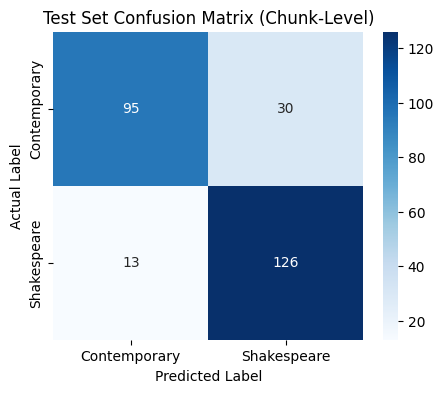

In [ ]:
final_scaler = StandardScaler()
X_train_final = final_scaler.fit_transform(X_train)
X_test_final = final_scaler.transform(X_test)
champion_model = SVC(kernel="linear", class_weight="balanced", probability=True, random_state=42)
champion_model.fit(X_train_final, y_train)
y_pred = champion_model.predict(X_test_final)
y_proba = champion_model.predict_proba(X_test_final)[:, 1]
print("=== FINAL TEST SET EVALUATION ===")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=["Contemporary (0)", "Shakespeare (1)"]))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Contemporary", "Shakespeare"],
            yticklabels=["Contemporary", "Shakespeare"])
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("Test Set Confusion Matrix (Chunk-Level)")
plt.show()

## Fit final models on full training set, evaluate on held-out test set

In [ ]:
final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train)
X_test_scaled = final_scaler.transform(X_test)
X_disputed_scaled = final_scaler.transform(X_disputed)
fitted_models = {}
test_results = {}

for name, (model, needs_scaling) in models.items():
    X_fit = X_train_scaled if needs_scaling else X_train
    X_eval = X_test_scaled if needs_scaling else X_test

    if name == "Gradient Boosting":
        sw = compute_sample_weight("balanced", y_train)
        model.fit(X_fit, y_train, sample_weight=sw)
    else:
        model.fit(X_fit, y_train)

    fitted_models[name] = model
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Contemporary", "Shakespeare"]))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {auc:.3f}")

    test_results[name] = {"f1_cv_mean": cv_results[name].mean(), "test_auc": auc}


=== Logistic Regression ===
              precision    recall  f1-score   support

Contemporary       0.87      0.80      0.83       125
 Shakespeare       0.83      0.89      0.86       139

    accuracy                           0.85       264
   macro avg       0.85      0.85      0.85       264
weighted avg       0.85      0.85      0.85       264

Confusion matrix:
 [[100  25]
 [ 15 124]]
ROC-AUC: 0.936

=== SVM (linear) ===
              precision    recall  f1-score   support

Contemporary       0.88      0.76      0.82       125
 Shakespeare       0.81      0.91      0.85       139

    accuracy                           0.84       264
   macro avg       0.84      0.83      0.83       264
weighted avg       0.84      0.84      0.84       264

Confusion matrix:
 [[ 95  30]
 [ 13 126]]
ROC-AUC: 0.931

=== Random Forest ===
              precision    recall  f1-score   support

Contemporary       1.00      0.63      0.77       125
 Shakespeare       0.75      1.00      0.86      

## Per-author recall check

In [ ]:
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_model = fitted_models[best_model_name]
needs_scaling = models[best_model_name][1]
X_eval = X_test_scaled if needs_scaling else X_test

print(f"Best model by CV F1: {best_model_name}")

test_df = test_df.reset_index(drop=True)
test_df["predicted"] = best_model.predict(X_eval)
test_df["correct"] = (test_df["predicted"] == test_df["label"])

per_author_recall = test_df.groupby("author")["correct"].mean().sort_values()
print("\nPer-author accuracy on test chunks (lower = weaker signal for that author):")
print(per_author_recall)

Best model by CV F1: Logistic Regression

Per-author accuracy on test chunks (lower = weaker signal for that author):
author
marlowe        0.333333
jonson         0.756757
greene         0.875000
shakespeare    0.892086
kyd            1.000000
fletcher       1.000000
massinger      1.000000
Name: correct, dtype: float64


In [ ]:
test_df["shakespeare_proba"] = best_model.predict_proba(X_eval)[:, 1]

weak_authors = ["jonson", "marlowe"]
weak_df = test_df[test_df["author"].isin(weak_authors)].copy()

print("Predicted-probability distribution by author, split by correct/incorrect:\n")
summary = weak_df.groupby(["author", "correct"])["shakespeare_proba"].agg(
    ["mean", "median", "std", "count"]
)
print(summary)

wrong = weak_df[~weak_df["correct"]]
confidently_wrong = wrong[(wrong["shakespeare_proba"] > 0.75) | (wrong["shakespeare_proba"] < 0.25)]
borderline_wrong = wrong[(wrong["shakespeare_proba"] >= 0.4) & (wrong["shakespeare_proba"] <= 0.6)]

print(f"\nOf {len(wrong)} misclassified Jonson/Marlowe chunks:")
print(f"  Confidently wrong (proba outside 0.25-0.75): {len(confidently_wrong)}")
print(f"  Borderline (proba 0.4-0.6): {len(borderline_wrong)}")

Predicted-probability distribution by author, split by correct/incorrect:

                     mean    median       std  count
author  correct                                     
jonson  False    0.873295  0.904624  0.120251      9
        True     0.094093  0.012770  0.140324     28
marlowe False    0.859758  0.934319  0.164778     14
        True     0.118557  0.122211  0.105039      7

Of 23 misclassified Jonson/Marlowe chunks:
  Confidently wrong (proba outside 0.25-0.75): 18
  Borderline (proba 0.4-0.6): 1


## Run the best model on the disputed texts


In [ ]:
X_disputed_eval = X_disputed_scaled if needs_scaling else X_disputed

disputed_df = disputed_df.reset_index(drop=True)
disputed_df["shakespeare_probability"] = best_model.predict_proba(X_disputed_eval)[:, 1]

print(f"Per-chunk predictions using: {best_model_name}\n")

per_work_summary = disputed_df.groupby("author")["shakespeare_probability"].agg(
    ["mean", "std", "min", "max", "count"]
).sort_values("mean", ascending=False)
print(per_work_summary)

Per-chunk predictions using: Logistic Regression

                      mean       std       min       max  count
author                                                         
henry_vi_part3    0.842198  0.311265  0.014050  0.999875     24
henry_vi_part2    0.802072  0.297035  0.002253  0.999987     24
double_falsehood  0.639265  0.409036  0.013098  0.997430     15
henry_vi_part1    0.576631  0.339448  0.007793  0.999950     21
spanish_tragedy   0.109066  0.225581  0.000008  0.808746     22


In [ ]:
with open(BASE_PATH + "modeling_results.pkl", "wb") as f:
    pickle.dump({
        "fitted_models": fitted_models,
        "best_model_name": best_model_name,
        "scaler": final_scaler,
        "cv_results": cv_results,
        "test_results": test_results,
        "test_df": test_df,
        "disputed_df": disputed_df,
    }, f)

print("Saved modeling_results.pkl to", BASE_PATH)